## 케글 수어 데이터셋
- 미국 수어(ASL, American Sign Language)의 알파벳 손짓을 $28 \times 28$ 흑백 이미지 형태의 수치 데이터로 변환한 데이터셋입니다.
- 포함 라벨: A, B, C, D, E, F, G, H, I, K, L, M, N, O, P, Q, R, S, T, U, V, W, X, Y
    - 제외된 라벨 (J, Z):
    - 알파벳 J와 Z는 정적인 손 모양이 아니라 손가락을 움직이는 동작(Motion)이 포함되어야 표현되는 수어입니다.
    - 단일 정지 이미지로는 표현할 수 없어 데이터셋에서 완전히 제외되었습니다. (라벨 9번과 25번이 비어 있음)

[케글 수어 데이터셋](https://www.kaggle.com/datasets/datamunge/sign-language-mnist)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

import torch
import torch.nn as nn
import torch.optim as optim

import sklearn
from sklearn.datasets import load_digits, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

# 데이터를 가져오는 모듈
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, Dataset, DataLoader

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# sklearn.set_config(display="text")

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
elif torch.xpu.is_available():
    device = torch.device("xpu")
else:
    device = torch.device("cpu")

print(f"현재 선택된 장치: {device}")

현재 선택된 장치: mps


In [6]:
base_path = "/Users/kdt_0900_cjs/ml/resource/dataset"
train_file_name = "sign_mnist_train.csv"
test_file_name = "sign_mnist_test.csv"
train_file_path = os.path.join(base_path, train_file_name)
test_file_path = os.path.join(base_path, test_file_name)

In [27]:
train_df = pd.read_csv(train_file_path)
test_df = pd.read_csv(test_file_path)

In [31]:
train_df.head(3)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195


In [32]:
test_df.head(3)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222


In [9]:
np.sqrt(784)

np.float64(28.0)

In [11]:
X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

In [14]:
len(pd.Series(y_train).unique())

24

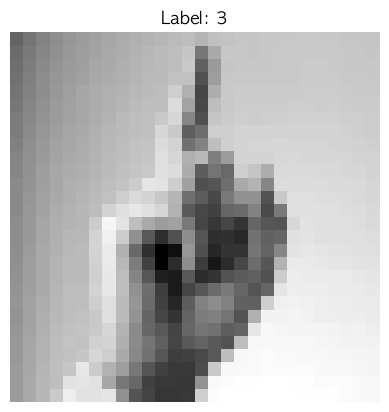

In [15]:
plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [25]:
import string

alphabets = [char for char in string.ascii_uppercase if char not in ["J", "Z"]]

classes_dict = {}
idx = 0
for char in string.ascii_uppercase:
    if char in ["J", "Z"]:
        continue
    classes_dict[idx] = char
    idx += 1 if char != "I" else 2

print(classes_dict)

{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y'}


## 데이터 증강 실습

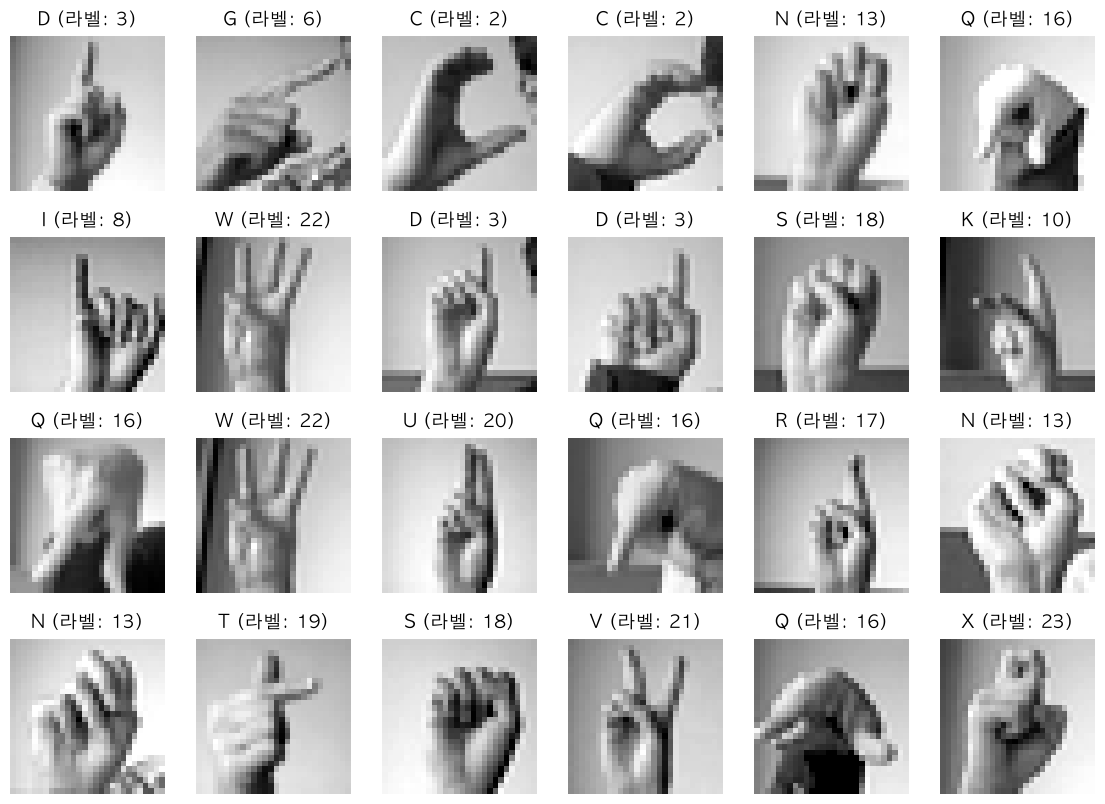

In [40]:
fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(14, 10))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i].reshape(28, 28), cmap="gray")
    ax.axis("off")
    key = y_train[i].item()
    ax.set_title(
        f"{classes_dict[key]} (라벨: {key})",
        fontsize=13,
        pad=8
    )
plt.show()

In [42]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32) / 255.0
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32) / 255.0
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [43]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [44]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), #50% 확률로 좌우 반전
    transforms.RandomRotation(degrees=10), # -10 ~ 10도까지 무작위 회전
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05), #가로, 세로 5% 범위 내에서 이미지 자신이 이동
        scale=(0.95, 1.05), #95 ~ 105% 범위 내에서 축소 및 확대
        shear=5, # 5도 비틀기
    ),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)) #20%의 확률로 이미지를 일부씩 가리는 노이즈 생성
])

test_transform = transforms.Compose([])

In [45]:
class AugmentDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    # 오버라이딩
    def __len__(self):
        return len(self.dataset)

    # 오버라이딩
    def __getitem__(self, idx):
        X, y = self.dataset[idx]
        # 그레이 스케일만 차원을 추가 (1, 28, 28)
        # 컬러라면 RGB 레이어가 있으므로 추가할 필요가 없다. (3, 28, 28)
        X = X.view(28, 28).unsqueeze(0)
        X = self.transform(X)
        return X.flatten(), y

In [46]:
train_agu_dataset = AugmentDataset(train_dataset, train_transform) 
test_agu_dataset = AugmentDataset(test_dataset, test_transform) 

In [47]:
train_loader = DataLoader(train_agu_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_agu_dataset, batch_size=64)


# train_loader = DataLoader(train_agu_dataset, batch_size=64, shuffle=True, num_workers=4)
# test_loader = DataLoader(test_agu_dataset, batch_size=64, num_workers=4)

In [48]:
imgs, labels = next(iter(train_loader))

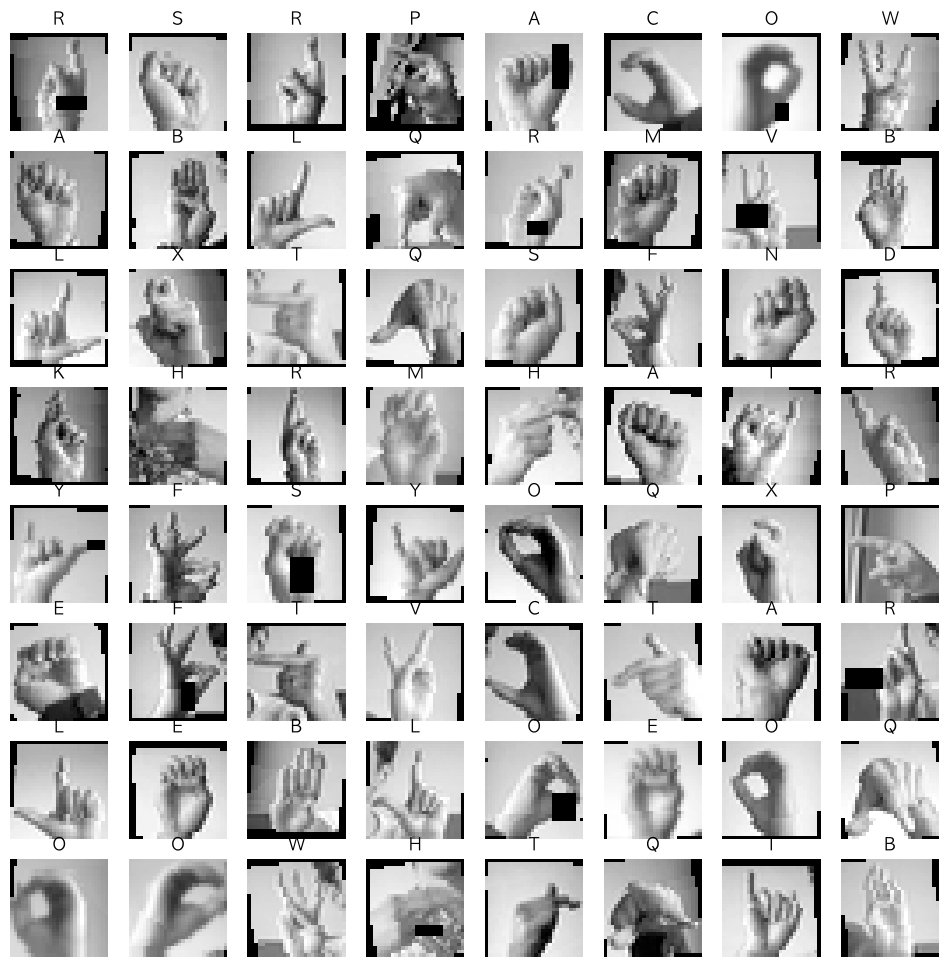

In [49]:
plt.figure(figsize=(12, 12))
for i in range(len(imgs)):
    plt.subplot(8, 8, i + 1)
    img = imgs[i].view(28, 28).numpy()

    label_idx = labels[i].item()
    class_name = classes_dict[label_idx]
    
    plt.imshow(img, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [56]:
model = nn.Sequential(
    nn.Linear(28 * 28, 25)
)

In [57]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [52]:
epochs = 50

for epoch in range(epochs):
    model.train()

    sum_losses = 0.0
    sum_accs = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad() # 기울기 초기화
        y_pred = model(X_batch) # 순전파
        loss = criterion(y_pred, y_batch) # 손실
        loss.backward() # 역전파
        optimizer.step() # 기울기 업데이트

        sum_losses += loss.item()
        y_pred_index = y_pred.argmax(dim=1)
        acc = (y_batch == y_pred_index).float().mean().item() * 100
        sum_accs += acc 

    avg_train_loss = sum_losses / len(train_loader)
    avg_train_acc = sum_accs / len(train_loader)

    print(f"Epoch: {epoch + 1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")

IndexError: Target 21 is out of bounds.

In [58]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
elif torch.xpu.is_available():
    device = torch.device("xpu")
else:
    device = torch.device("cpu")

print(f"현재 선택된 장치: {device}")

현재 선택된 장치: mps


In [59]:
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 50

for epoch in range(epochs):
    model.train()

    sum_losses = 0.0
    sum_accs = 0.0

    for X_batch, y_batch in train_loader:
        X_batch=X_batch.to(device)
        y_batch=y_batch.to(device)
        optimizer.zero_grad() # 기울기 초기화
        y_pred = model(X_batch) # 순전파
        loss = criterion(y_pred, y_batch) # 손실
        loss.backward() # 역전파
        optimizer.step() # 기울기 업데이트

        sum_losses += loss.item()
        y_pred_index = y_pred.argmax(dim=1)
        acc = (y_batch == y_pred_index).float().mean().item() * 100
        sum_accs += acc 

    avg_train_loss = sum_losses / len(train_loader)
    avg_train_acc = sum_accs / len(train_loader)

    print(f"Epoch: {epoch + 1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")

Epoch: 1/50 | Train Loss: 2.2875 | Train Acc: 34.64%
Epoch: 2/50 | Train Loss: 2.2455 | Train Acc: 35.76%
Epoch: 3/50 | Train Loss: 2.2332 | Train Acc: 36.46%
Epoch: 4/50 | Train Loss: 2.1977 | Train Acc: 37.36%
Epoch: 5/50 | Train Loss: 2.1976 | Train Acc: 37.38%
Epoch: 6/50 | Train Loss: 2.1614 | Train Acc: 38.73%
Epoch: 7/50 | Train Loss: 2.1625 | Train Acc: 38.86%
Epoch: 8/50 | Train Loss: 2.1432 | Train Acc: 39.42%
Epoch: 9/50 | Train Loss: 2.1464 | Train Acc: 39.46%
Epoch: 10/50 | Train Loss: 2.1295 | Train Acc: 39.93%
Epoch: 11/50 | Train Loss: 2.1409 | Train Acc: 39.50%
Epoch: 12/50 | Train Loss: 2.1147 | Train Acc: 40.68%
Epoch: 13/50 | Train Loss: 2.1254 | Train Acc: 40.37%
Epoch: 14/50 | Train Loss: 2.1000 | Train Acc: 40.92%
Epoch: 15/50 | Train Loss: 2.1176 | Train Acc: 40.53%
Epoch: 16/50 | Train Loss: 2.1128 | Train Acc: 40.54%
Epoch: 17/50 | Train Loss: 2.1069 | Train Acc: 40.79%
Epoch: 18/50 | Train Loss: 2.1032 | Train Acc: 40.74%
Epoch: 19/50 | Train Loss: 2.1022 | T